# LSTM + BỘ DỮ LIỆU AMPDiscover

In [45]:
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None  # default='warn'
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
from sklearn.metrics import classification_report,confusion_matrix, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay

from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import  Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, Concatenate, Reshape, Embedding, GlobalAveragePooling1D, Lambda
from collections import Counter
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Dropout, BatchNormalization, Conv1D, GlobalMaxPooling1D

# Nhập và tiền xử lý dữ liệu

In [48]:
import pandas as pd

# Đọc file
df_train = pd.read_csv(r'AmpHGT_data/csv_AMPDiscover/AMPDiscovery_features_train.csv')

# Lọc từng nhóm
df_amp = df_train[df_train['label'] == 'AMP']
df_namp = df_train[df_train['label'] == 'nAMP']

# Lấy đúng 2000 dòng mỗi nhóm
df_amp_sample = df_amp.sample(n=4600, random_state=42)
df_namp_sample = df_namp.sample(n=4600, random_state=42)

# Gộp lại
df_train = pd.concat([df_amp_sample, df_namp_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Số lượng AMP:", len(df_amp_sample))
print("Số lượng nAMP:", len(df_namp_sample))
df_train.head()

Số lượng AMP: 4600
Số lượng nAMP: 4600


,id,sequence,label,hydrophobicity_polar_first,hydrophobicity_polar_20%,hydrophobicity_polar_40%,hydrophobicity_polar_60%,hydrophobicity_polar_80%,hydrophobicity_polar_100%,hydrophobicity_neutral_first,...,solvent_accessibility_intermediate_40%,solvent_accessibility_intermediate_60%,solvent_accessibility_intermediate_80%,solvent_accessibility_intermediate_100%,solvent_accessibility_exposed_first,solvent_accessibility_exposed_20%,solvent_accessibility_exposed_40%,solvent_accessibility_exposed_60%,solvent_accessibility_exposed_80%,solvent_accessibility_exposed_100%
0,Sequence_1512_Neg_train,RHLSAEEVFRRLL,nAMP,7.692308,46.153846,53.846154,76.923077,84.615385,84.615385,15.384615,...,15.384615,30.769231,30.769231,30.769231,7.692308,46.153846,53.846154,76.923077,84.615385,84.615385
1,seq7406_train,GLPTCGETCFGGTCNTPGCSCSSWPICTRN,AMP,23.333333,23.333333,50.000000,96.666667,100.000000,100.000000,3.333333,...,53.333333,66.666667,76.666667,93.333333,23.333333,23.333333,50.000000,96.666667,100.000000,100.000000
2,seq2229_train,KVASVIGGL,AMP,11.111111,11.111111,11.111111,11.111111,11.111111,11.111111,33.333333,...,44.444444,44.444444,44.444444,44.444444,11.111111,11.111111,11.111111,11.111111,11.111111,11.111111
3,Sequence_8379_Neg_train,KDSVHTRKLTVSRKYVASQLRNGRYDPKILIAGQWLSSCGFNPGHK...,nAMP,1.515152,19.696970,36.363636,69.696970,90.909091,100.000000,4.545455,...,27.272727,56.060606,68.181818,98.484848,1.515152,19.696970,36.363636,69.696970,90.909091,100.000000
4,Sequence_8173_Neg_train,PVMNSEYFAKTKKVIEEKAGVSPSEIHESSFFEDDLNVGEMELLEI...,nAMP,7.142857,23.214286,44.642857,62.500000,80.357143,98.214286,1.785714,...,39.285714,48.214286,73.214286,94.642857,7.142857,23.214286,44.642857,62.500000,80.357143,98.214286


In [54]:
import pandas as pd

# Đọc file
df_test = pd.read_csv(r'AmpHGT_data/csv_AMPDiscover/AMPDiscovery_features_test.csv')

# Lọc từng nhóm
df_amp = df_test[df_test['label'] == 'AMP']
df_namp = df_test[df_test['label'] == 'nAMP']

# Lấy đúng 2000 dòng mỗi nhóm
df_amp_sample = df_amp.sample(n=500, random_state=42)
df_namp_sample = df_namp.sample(n=500, random_state=42)

# Gộp lại
df_test = pd.concat([df_amp_sample, df_namp_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Số lượng AMP:", len(df_amp_sample))
print("Số lượng nAMP:", len(df_namp_sample))
df_test.head()

Số lượng AMP: 500
Số lượng nAMP: 500


,id,sequence,label,hydrophobicity_polar_first,hydrophobicity_polar_20%,hydrophobicity_polar_40%,hydrophobicity_polar_60%,hydrophobicity_polar_80%,hydrophobicity_polar_100%,hydrophobicity_neutral_first,...,solvent_accessibility_intermediate_40%,solvent_accessibility_intermediate_60%,solvent_accessibility_intermediate_80%,solvent_accessibility_intermediate_100%,solvent_accessibility_exposed_first,solvent_accessibility_exposed_20%,solvent_accessibility_exposed_40%,solvent_accessibility_exposed_60%,solvent_accessibility_exposed_80%,solvent_accessibility_exposed_100%
0,Sequence_7079_Neg_test,MCEKIFGPTKDWECYCGKYKRVRYKGIICDRCGVEVTTKNVRRERM...,nAMP,3.797468,16.455696,31.645570,50.632911,78.481013,98.734177,8.860759,...,48.101266,68.354430,82.278481,96.202532,3.797468,16.455696,31.645570,50.632911,78.481013,98.734177
1,Sequence_10142_Neg_test,EVKEAYEILSDSQKRG,nAMP,6.250000,18.750000,43.750000,68.750000,87.500000,93.750000,31.250000,...,62.500000,62.500000,75.000000,75.000000,6.250000,18.750000,43.750000,68.750000,87.500000,93.750000
2,Sequence_5585_Neg_test,RECIQVLRDILMTAKTVILSDGDISAETI,nAMP,3.448276,6.896552,27.586207,51.724138,79.310345,93.103448,44.827586,...,55.172414,68.965517,86.206897,96.551724,3.448276,6.896552,27.586207,51.724138,79.310345,93.103448
3,Sequence_8962_Neg_test,ALRDATFCFIVLLAVADVAVGALVIP,nAMP,11.538462,11.538462,15.384615,15.384615,65.384615,65.384615,3.846154,...,23.076923,100.000000,100.000000,100.000000,11.538462,11.538462,15.384615,15.384615,65.384615,65.384615
4,Sequence_2490_Pos_test,ALWKSLLKNVGKAAGKAALNAVTDMVNQ,AMP,14.285714,28.571429,42.857143,71.428571,96.428571,100.000000,3.571429,...,82.142857,82.142857,89.285714,89.285714,14.285714,28.571429,42.857143,71.428571,96.428571,100.000000


In [56]:
import pandas as pd

# Đọc file
df_val = pd.read_csv(r'AmpHGT_data/csv_AMPDiscover/AMPDiscovery_features_val.csv')

# Lọc từng nhóm
df_amp = df_val[df_val['label'] == 'AMP']
df_namp = df_val[df_val['label'] == 'nAMP']

# Lấy đúng 2000 dòng mỗi nhóm
df_amp_sample = df_amp.sample(n=500, random_state=42)
df_namp_sample = df_namp.sample(n=500, random_state=42)

# Gộp lại
df_val = pd.concat([df_amp_sample, df_namp_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Số lượng AMP:", len(df_amp_sample))
print("Số lượng nAMP:", len(df_namp_sample))
df_val.head()

Số lượng AMP: 500
Số lượng nAMP: 500


,id,sequence,label,hydrophobicity_polar_first,hydrophobicity_polar_20%,hydrophobicity_polar_40%,hydrophobicity_polar_60%,hydrophobicity_polar_80%,hydrophobicity_polar_100%,hydrophobicity_neutral_first,...,solvent_accessibility_intermediate_40%,solvent_accessibility_intermediate_60%,solvent_accessibility_intermediate_80%,solvent_accessibility_intermediate_100%,solvent_accessibility_exposed_first,solvent_accessibility_exposed_20%,solvent_accessibility_exposed_40%,solvent_accessibility_exposed_60%,solvent_accessibility_exposed_80%,solvent_accessibility_exposed_100%
0,Sequence_555_Neg_val,VSPPSVNQWIKGVRQLPAER,nAMP,35.000000,40.000000,55.000000,75.000000,95.000000,100.0,10.000000,...,20.000000,25.000000,85.000000,85.000000,35.000000,40.000000,55.000000,75.000000,95.000000,100.0
1,Sequence_1699_Neg_val,PGAEARTALAVCRRCPVLLDCRNWAVEHGEDAGIWGATTAAQRRAV...,nAMP,4.347826,21.739130,33.695652,51.086957,72.826087,100.0,1.086957,...,64.130435,76.086957,90.217391,96.739130,4.347826,21.739130,33.695652,51.086957,72.826087,100.0
2,Sequence_1651_Neg_val,FMPRKTSQLAFDQAILELESVVKKLEAGEVTLEESIELYKQGINLA...,nAMP,6.557377,27.868852,47.540984,67.213115,88.524590,100.0,4.918033,...,11.475410,50.819672,63.934426,81.967213,6.557377,27.868852,47.540984,67.213115,88.524590,100.0
3,Sequence_1954_Neg_val,EITVTRVGGSTVDGK,nAMP,6.666667,6.666667,40.000000,86.666667,100.000000,100.0,20.000000,...,33.333333,66.666667,73.333333,73.333333,6.666667,6.666667,40.000000,86.666667,100.000000,100.0
4,Sequence_1715_Pos_val,RSELIVHQR,AMP,11.111111,11.111111,33.333333,88.888889,100.000000,100.0,22.222222,...,22.222222,77.777778,77.777778,77.777778,11.111111,11.111111,33.333333,88.888889,100.000000,100.0


### Cột "ID" có thể chỉ là một định danh duy nhất cho từng dòng, không mang ý nghĩa đặc biệt trong mô hình.

In [59]:
# df_train = df_train.drop(columns=['id'])
# df_val = df_val.drop(columns=['id'])
# df_test = df_test.drop(columns=['id'])

In [61]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9200 entries, 0 to 9199
Columns: 129 entries, id to solvent_accessibility_exposed_100%
dtypes: float64(126), object(3)
memory usage: 9.1+ MB


In [63]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 129 entries, id to solvent_accessibility_exposed_100%
dtypes: float64(126), object(3)
memory usage: 1007.9+ KB


In [65]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 129 entries, id to solvent_accessibility_exposed_100%
dtypes: float64(126), object(3)
memory usage: 1007.9+ KB


### Chuyển đổi nhãn (Label) từ chuỗi sang số (0/1):
#### - Nếu Label == 'nAMP' → gán 0 (Không kháng khuẩn).
#### - Nếu không phải 'nAMP' → gán 1 (Kháng khuẩn).
### Chuyển đổi kiểu dữ liệu thành float để phù hợp với mô hình.

In [68]:
dic = {'nAMP': 0, 'AMP': 1}
df_train['label'] = df_train['label'].map(dic)
df_test['label'] = df_test['label'].map(dic)
df_val['label'] = df_val['label'].map(dic)

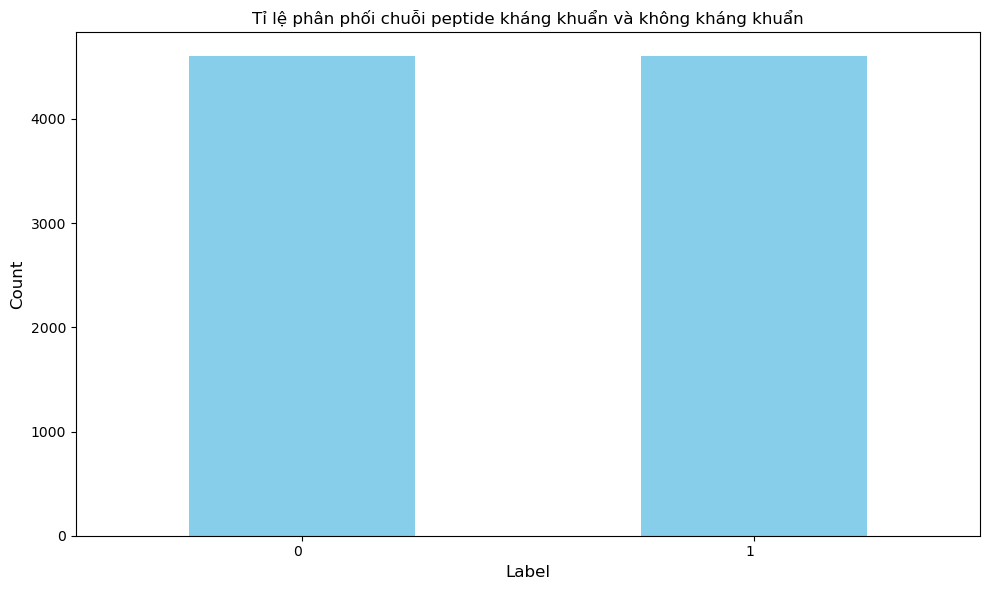

In [70]:
label_counts = df_train['label'].value_counts()
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color = 'skyblue')
plt.title('Tỉ lệ phân phối chuỗi peptide kháng khuẩn và không kháng khuẩn')
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

In [71]:
df_train.head()

,id,sequence,label,hydrophobicity_polar_first,hydrophobicity_polar_20%,hydrophobicity_polar_40%,hydrophobicity_polar_60%,hydrophobicity_polar_80%,hydrophobicity_polar_100%,hydrophobicity_neutral_first,...,solvent_accessibility_intermediate_40%,solvent_accessibility_intermediate_60%,solvent_accessibility_intermediate_80%,solvent_accessibility_intermediate_100%,solvent_accessibility_exposed_first,solvent_accessibility_exposed_20%,solvent_accessibility_exposed_40%,solvent_accessibility_exposed_60%,solvent_accessibility_exposed_80%,solvent_accessibility_exposed_100%
0,Sequence_1512_Neg_train,RHLSAEEVFRRLL,0,7.692308,46.153846,53.846154,76.923077,84.615385,84.615385,15.384615,...,15.384615,30.769231,30.769231,30.769231,7.692308,46.153846,53.846154,76.923077,84.615385,84.615385
1,seq7406_train,GLPTCGETCFGGTCNTPGCSCSSWPICTRN,1,23.333333,23.333333,50.000000,96.666667,100.000000,100.000000,3.333333,...,53.333333,66.666667,76.666667,93.333333,23.333333,23.333333,50.000000,96.666667,100.000000,100.000000
2,seq2229_train,KVASVIGGL,1,11.111111,11.111111,11.111111,11.111111,11.111111,11.111111,33.333333,...,44.444444,44.444444,44.444444,44.444444,11.111111,11.111111,11.111111,11.111111,11.111111,11.111111
3,Sequence_8379_Neg_train,KDSVHTRKLTVSRKYVASQLRNGRYDPKILIAGQWLSSCGFNPGHK...,0,1.515152,19.696970,36.363636,69.696970,90.909091,100.000000,4.545455,...,27.272727,56.060606,68.181818,98.484848,1.515152,19.696970,36.363636,69.696970,90.909091,100.000000
4,Sequence_8173_Neg_train,PVMNSEYFAKTKKVIEEKAGVSPSEIHESSFFEDDLNVGEMELLEI...,0,7.142857,23.214286,44.642857,62.500000,80.357143,98.214286,1.785714,...,39.285714,48.214286,73.214286,94.642857,7.142857,23.214286,44.642857,62.500000,80.357143,98.214286


In [72]:
X_test = df_test.drop(columns=['label', 'id'])
y_test = df_test['label']

X_train = df_train.drop(columns=['label', 'id'])
y_train = df_train['label']

X_val = df_val.drop(columns=['label', 'id'])
y_val = df_val['label']

### Kiểm tra (mẫu, đặc trưng)

In [75]:
print(X_test.shape)
print(y_test.shape)

print(X_train.shape)
print(y_train.shape)

(1000, 127)
(1000,)
(9200, 127)
(9200,)


### chuỗi sequence dạng chữ, chuyển về chuỗi số

### Đệm hoặc cắt ở phía sau
###  Lý do chọn 'post':
#### - Giữ thông tin quan trọng ở đầu chuỗi, vì đầu peptide có thể chứa thông tin quan trọng về tính kháng khuẩn.

In [81]:
# pip install tensorflow

In [82]:
max_length = 50
padding_type = 'post' # Đệm thêm số 0
trunc_type = 'post'  # Cắt nếu chuỗi dài

In [83]:
#help(Tokenizer)

In [84]:
tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(df_train['sequence'])
vocab_size = len(tokenizer.word_index) + 1
print("Vocab Size: ",vocab_size)

Vocab Size:  21


In [85]:
tokenizer.word_index #bộ tự điện ánh xa qua số

{'l': 1,
 'k': 2,
 'a': 3,
 'e': 4,
 'g': 5,
 'v': 6,
 's': 7,
 'r': 8,
 'i': 9,
 'd': 10,
 't': 11,
 'f': 12,
 'p': 13,
 'n': 14,
 'q': 15,
 'c': 16,
 'm': 17,
 'y': 18,
 'h': 19,
 'w': 20}

In [89]:
train_sequences  = tokenizer.texts_to_sequences(X_train['sequence'])
train_sequence_array = pad_sequences(train_sequences , maxlen= max_length, padding= padding_type, truncating=trunc_type)

val_sequences = tokenizer.texts_to_sequences(X_val['sequence'])
val_sequence_array = pad_sequences(val_sequences , maxlen= max_length, padding= padding_type, truncating=trunc_type)

test_sequences = tokenizer.texts_to_sequences(X_test['sequence'])
test_sequence_array = pad_sequences(test_sequences , maxlen= max_length, padding= padding_type, truncating=trunc_type)

In [92]:
train_sequence_array.shape, val_sequence_array.shape, test_sequence_array.shape

((9200, 50), (1000, 50), (1000, 50))

In [95]:
X_train.head()

,sequence,hydrophobicity_polar_first,hydrophobicity_polar_20%,hydrophobicity_polar_40%,hydrophobicity_polar_60%,hydrophobicity_polar_80%,hydrophobicity_polar_100%,hydrophobicity_neutral_first,hydrophobicity_neutral_20%,hydrophobicity_neutral_40%,...,solvent_accessibility_intermediate_40%,solvent_accessibility_intermediate_60%,solvent_accessibility_intermediate_80%,solvent_accessibility_intermediate_100%,solvent_accessibility_exposed_first,solvent_accessibility_exposed_20%,solvent_accessibility_exposed_40%,solvent_accessibility_exposed_60%,solvent_accessibility_exposed_80%,solvent_accessibility_exposed_100%
0,RHLSAEEVFRRLL,7.692308,46.153846,53.846154,76.923077,84.615385,84.615385,15.384615,15.384615,30.769231,...,15.384615,30.769231,30.769231,30.769231,7.692308,46.153846,53.846154,76.923077,84.615385,84.615385
1,GLPTCGETCFGGTCNTPGCSCSSWPICTRN,23.333333,23.333333,50.000000,96.666667,100.000000,100.000000,3.333333,20.000000,40.000000,...,53.333333,66.666667,76.666667,93.333333,23.333333,23.333333,50.000000,96.666667,100.000000,100.000000
2,KVASVIGGL,11.111111,11.111111,11.111111,11.111111,11.111111,11.111111,33.333333,33.333333,44.444444,...,44.444444,44.444444,44.444444,44.444444,11.111111,11.111111,11.111111,11.111111,11.111111,11.111111
3,KDSVHTRKLTVSRKYVASQLRNGRYDPKILIAGQWLSSCGFNPGHK...,1.515152,19.696970,36.363636,69.696970,90.909091,100.000000,4.545455,18.181818,34.848485,...,27.272727,56.060606,68.181818,98.484848,1.515152,19.696970,36.363636,69.696970,90.909091,100.000000
4,PVMNSEYFAKTKKVIEEKAGVSPSEIHESSFFEDDLNVGEMELLEI...,7.142857,23.214286,44.642857,62.500000,80.357143,98.214286,1.785714,16.071429,35.714286,...,39.285714,48.214286,73.214286,94.642857,7.142857,23.214286,44.642857,62.500000,80.357143,98.214286


In [96]:
X_train = X_train.drop(columns=['sequence'])
X_train['train_sequences'] = train_sequence_array.tolist()

X_val= X_val.drop(columns=['sequence'])
X_val['val_sequences'] = val_sequence_array.tolist()

X_test= X_test.drop(columns=['sequence'])
X_test['test_sequences'] = test_sequence_array.tolist()

In [97]:
X_train.head()

,hydrophobicity_polar_first,hydrophobicity_polar_20%,hydrophobicity_polar_40%,hydrophobicity_polar_60%,hydrophobicity_polar_80%,hydrophobicity_polar_100%,hydrophobicity_neutral_first,hydrophobicity_neutral_20%,hydrophobicity_neutral_40%,hydrophobicity_neutral_60%,...,solvent_accessibility_intermediate_60%,solvent_accessibility_intermediate_80%,solvent_accessibility_intermediate_100%,solvent_accessibility_exposed_first,solvent_accessibility_exposed_20%,solvent_accessibility_exposed_40%,solvent_accessibility_exposed_60%,solvent_accessibility_exposed_80%,solvent_accessibility_exposed_100%,train_sequences
0,7.692308,46.153846,53.846154,76.923077,84.615385,84.615385,15.384615,15.384615,30.769231,30.769231,...,30.769231,30.769231,30.769231,7.692308,46.153846,53.846154,76.923077,84.615385,84.615385,"[8, 19, 1, 7, 3, 4, 4, 6, 12, 8, 8, 1, 1, 0, 0..."
1,23.333333,23.333333,50.000000,96.666667,100.000000,100.000000,3.333333,20.000000,40.000000,56.666667,...,66.666667,76.666667,93.333333,23.333333,23.333333,50.000000,96.666667,100.000000,100.000000,"[5, 1, 13, 11, 16, 5, 4, 11, 16, 12, 5, 5, 11,..."
2,11.111111,11.111111,11.111111,11.111111,11.111111,11.111111,33.333333,33.333333,44.444444,77.777778,...,44.444444,44.444444,44.444444,11.111111,11.111111,11.111111,11.111111,11.111111,11.111111,"[2, 6, 3, 7, 6, 9, 5, 5, 1, 0, 0, 0, 0, 0, 0, ..."
3,1.515152,19.696970,36.363636,69.696970,90.909091,100.000000,4.545455,18.181818,34.848485,50.000000,...,56.060606,68.181818,98.484848,1.515152,19.696970,36.363636,69.696970,90.909091,100.000000,"[2, 10, 7, 6, 19, 11, 8, 2, 1, 11, 6, 7, 8, 2,..."
4,7.142857,23.214286,44.642857,62.500000,80.357143,98.214286,1.785714,16.071429,35.714286,42.857143,...,48.214286,73.214286,94.642857,7.142857,23.214286,44.642857,62.500000,80.357143,98.214286,"[13, 6, 17, 14, 7, 4, 18, 12, 3, 2, 11, 2, 2, ..."


In [98]:
X_train.describe()

,hydrophobicity_polar_first,hydrophobicity_polar_20%,hydrophobicity_polar_40%,hydrophobicity_polar_60%,hydrophobicity_polar_80%,hydrophobicity_polar_100%,hydrophobicity_neutral_first,hydrophobicity_neutral_20%,hydrophobicity_neutral_40%,hydrophobicity_neutral_60%,...,solvent_accessibility_intermediate_40%,solvent_accessibility_intermediate_60%,solvent_accessibility_intermediate_80%,solvent_accessibility_intermediate_100%,solvent_accessibility_exposed_first,solvent_accessibility_exposed_20%,solvent_accessibility_exposed_40%,solvent_accessibility_exposed_60%,solvent_accessibility_exposed_80%,solvent_accessibility_exposed_100%
count,9200.000000,9200.000000,9200.000000,9200.000000,9200.000000,9200.000000,9200.000000,9200.000000,9200.000000,9200.000000,...,9200.000000,9200.000000,9200.000000,9200.000000,9200.000000,9200.000000,9200.000000,9200.000000,9200.000000,9200.000000
mean,16.031598,28.286640,45.010952,61.958148,78.797782,88.541090,14.845700,26.824002,43.673816,60.843956,...,42.246049,57.505422,72.208299,78.693031,16.031598,28.286640,45.010952,61.958148,78.797782,88.541090
std,17.411410,16.084479,16.801829,17.346190,17.368620,18.340427,17.047024,15.976153,17.631463,19.085068,...,21.901060,23.955347,26.222564,28.194492,17.411410,16.084479,16.801829,17.346190,17.368620,18.340427
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,16.666667,34.042553,53.191489,72.580645,85.881696,4.166667,16.666667,33.333333,53.333333,...,28.169014,46.153846,66.666667,73.050936,5.000000,16.666667,34.042553,53.191489,72.580645,85.881696
50%,9.090909,25.000000,44.444444,62.500000,82.352941,95.454545,8.333333,24.137931,43.750000,62.962963,...,41.666667,61.111111,80.000000,90.000000,9.090909,25.000000,44.444444,62.500000,82.352941,95.454545
75%,20.000000,36.111111,53.846154,72.727273,90.000000,100.000000,19.230769,33.333333,53.846154,72.347424,...,56.250000,73.437500,89.247312,97.560976,20.000000,36.111111,53.846154,72.727273,90.000000,100.000000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [101]:
columns_with_max_equal_1 = X_train.columns[X_train.max() == 1]
columns_with_min_equal_0 = X_train.columns[X_train.min() == 0]

# In kết quả
print("Các cột có max == 1:", len(list(columns_with_max_equal_1)))
print("Các cột có min == 0:", len(list(columns_with_min_equal_0)))

Các cột có max == 1: 0
Các cột có min == 0: 126


## Kiểm tra X_train
#### Tổng có 127 cột. Tách thành 126 + 1 cột mảng

In [105]:
print(X_train.dtypes.value_counts())

float64    126
object       1
Name: count, dtype: int64


In [108]:
X_train_num = X_train.iloc[:, :126]  # Chọn 126 cột đầu tiên
X_train_text = X_train.iloc[:, -1]   # Chọn cột cuối cùng

## Kiểm tra X_val
#### Tổng có 127 cột. Tách thành 126 + 1 cột mảng

In [110]:
X_val_num = X_val.iloc[:, :126]  # Chọn 126 cột đầu tiên
X_val_text = X_val.iloc[:, -1]   # Chọn cột cuối cùng

In [111]:
X_val_text.shape, X_train_text.shape

((1000,), (9200,))

## Kiểm tra dữ liệu huấn luyện
In thử một vài giá trị trong X_train và X_val để kiểm tra xem có giá trị âm hoặc không hợp lệ không

In [116]:
np.array([np.array(row) for row in X_train_text.values])

array([[ 8, 19,  1, ...,  0,  0,  0],
       [ 5,  1, 13, ...,  0,  0,  0],
       [ 2,  6,  3, ...,  0,  0,  0],
       ...,
       [ 1, 10,  7, ...,  0,  0,  0],
       [12, 12, 19, ...,  0,  0,  0],
       [ 3,  4,  1, ...,  0,  0,  0]])

### MODEL LSTM

In [118]:
import numpy as np

# Số timestep (phải khớp với chiều thứ 2 của X_train_text)
timesteps = 50  # ví dụ: 50
X_train_text = np.array([np.array(row) for row in X_train_text.values])
X_val_text = np.array([np.array(row) for row in X_val_text.values])

# Reshape từ (samples, timesteps) => (samples, timesteps, 1)
X_train_seq = X_train_text.reshape(-1, timesteps, 1)
X_val_seq = X_val_text.reshape(-1, timesteps, 1)

# Đặc trưng số học thành mảng 3D
X_train_num_np = X_train_num.values.reshape(-1, 126, 1).astype(np.float32)
X_val_num_np = X_val_num.values.reshape(-1, 126, 1).astype(np.float32)

# Nhãn đầu ra
y_train_np = y_train.values.reshape(-1, 1).astype(np.float32)
y_val_np = y_val.values.reshape(-1, 1).astype(np.float32)
y_test_np = y_test.values.reshape(-1, 1).astype(np.float32)

In [119]:
X_train_seq.shape, X_train_text.shape, X_train_num.shape

((9200, 50, 1), (9200, 50), (9200, 126))

In [120]:


# === Tham số mô hình ===
#num_timesteps_num = X_train_num_np.shape[1]   # 126
#num_features_num = X_train_num_np.shape[2]    # 1
num_timesteps_num = X_train_num.shape[1]
#num_features_num = X_train_num.shape[1:]
timesteps = X_train_text.shape[1]              # ví dụ: 50
print(timesteps)
vocab_size = X_train_seq.max() + 1            # nếu là categorical input thì dùng Embedding

embedding_dim = 128
lstm_units = 128
dropout_rate = 0.2
dense_1_units = 256
dense_2_units = 512
output_units = 1  

# === Nhánh 1: Dữ liệu chuỗi ===
#sequence_input = Input(shape=(timesteps, 1), name="sequence_input")
sequence_input = Input(shape=(timesteps, ), name="sequence_input")
x1 = Embedding(input_dim=vocab_size, output_dim=embedding_dim)(sequence_input)
x1 = LSTM(lstm_units, return_sequences=False)(x1)
x1 = BatchNormalization(name = "BatchNormalizationLSTM")(x1)
x1 = Dropout(dropout_rate)(x1)

# sequence_input = Input(shape=(timesteps,), name="sequence_input")  # KHÔNG có dimension cuối là (1)
# x1 = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=timesteps)(sequence_input)
# x1 = LSTM(lstm_units, return_sequences=False)(x1)
# x1 = BatchNormalization()(x1)
# x1 = Dropout(dropout_rate)(x1)

# === Nhánh 2: Dữ liệu số ===
numerical_input = Input(shape=(num_timesteps_num, 1), name="numerical_input")
#numerical_input = Input(shape=(num_timesteps_num, num_features_num), name="numerical_input")

#x2 = LSTM(lstm_units, return_sequences=False)(numerical_input)
x2 = Conv1D(filters=64, kernel_size=3, activation='relu')(numerical_input)
x2 = GlobalMaxPooling1D()(x2)
x2 = BatchNormalization(name = "BatchNormalizationNumerical")(x2)
x2 = Dropout(dropout_rate)(x2)

# === Kết hợp hai nhánh ===
combined = Concatenate()([x1, x2])

# === Dense layers ===
x = Dense(dense_1_units, activation='relu')(combined)
x = BatchNormalization()(x)
x = Dropout(dropout_rate)(x)
x = Dense(dense_2_units, activation='relu')(x)
x = BatchNormalization()(x)

# === Output ===
#output = Dense(output_units, activation='linear', name="output")(x)  # Nếu regression
output = Dense(output_units, activation='sigmoid', name="output")(x)

50


In [122]:
sequence_input.shape, numerical_input.shape

((None, 50), (None, 126, 1))

In [125]:
# === Tạo model ===
model = Model(inputs=[sequence_input, numerical_input], outputs=output)

# === Compile model ===
optimizer = Adam(learning_rate=0.00001)  # Tăng learning rate nhẹ lên từ 1e-5 → 1e-4 thuat toan adam chi cạp nhat trong so
#model.compile(optimizer=optimizer, loss="mse", metrics=["accuracy"])
model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"]) #sigmol là quan tam toi output
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)   │ (None, 50)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ numerical_input (InputLayer)  │ (None, 126, 1)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 50, 128)           │           2,688 │ sequence_input[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 124, 64)           │             256 │ numerical_input[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 128)               │         131,584 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d          │ (None, 64)                │               0 │ conv1d[0][0]               │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ BatchNormalizationLSTM        │ (None, 128)               │             512 │ lstm[0][0]                 │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ BatchNormalizationNumerical   │ (None, 64)                │             256 │ global_max_pooling1d[0][0] │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ BatchNormalizationLSTM[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 64)                │               0 │ BatchNormalizationNumeric… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 192)               │               0 │ dropout[0][0],             │
│                               │                           │                 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 256)               │          49,408 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 256)               │           1,024 │ dense[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 256)               │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 512)               │         131,58

 Total params: 319,873 (1.22 MB)

 Trainable params: 317,953 (1.21 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [89]:
# model.summary(line_length=200, expand_nested=True)

In [90]:
# ! pip install pydot

In [129]:
# === Callbacks ===
weight_path = "{}_weights.best.weights.h5".format('lstm_AMPDiscover')

checkpoint = ModelCheckpoint(
    filepath=weight_path,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=True,
    mode='min'
)

early = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=149,
    verbose=1,
    restore_best_weights=True
)

reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

callbacks_list = [checkpoint, early, reduce]

In [131]:
X_train_seq.shape, X_train_num_np.shape

((9200, 50, 1), (9200, 126, 1))

In [133]:
X_train_num.shape, X_train_text.shape

((9200, 126), (9200, 50))

In [135]:
# # === Huấn luyện ===
# history = model.fit(
#     [X_train_text, X_train_num_np],
#     y_train_np,
#     validation_data=([X_val_seq, X_val_num_np], y_val_np),
#     #validation_data=([X_val_text, X_val_num], y_val_np),
#     #validation_split = 0.2,
#     #validation_split = 0.2,
#     epochs=100,
#     batch_size=32,
#     callbacks=callbacks_list
# )

In [137]:
from tensorflow.keras.callbacks import CSVLogger

# Callback lưu log sau mỗi epoch
csv_logger = CSVLogger("AMPDiscover_training_log.csv", append=False)

# Huấn luyện
history = model.fit(
    [X_train_text, X_train_num_np],
    y_train_np,
    validation_data=([X_val_seq, X_val_num_np], y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=callbacks_list + [csv_logger]  # thêm vào list callback của bạn
)

Epoch 1/100
287/288 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5206 - loss: 0.8509
Epoch 1: val_loss improved from inf to 0.71969, saving model to lstm_AMPDiscover_weights.best.weights.h5
288/288 ━━━━━━━━━━━━━━━━━━━━ 28s 48ms/step - accuracy: 0.5209 - loss: 0.8505 - val_accuracy: 0.5160 - val_loss: 0.7197 - learning_rate: 1.0000e-05
Epoch 2/100
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5914 - loss: 0.7328
Epoch 2: val_loss improved from 0.71969 to 0.63373, saving model to lstm_AMPDiscover_weights.best.weights.h5
288/288 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.5915 - loss: 0.7328 - val_accuracy: 0.6390 - val_loss: 0.6337 - learning_rate: 1.0000e-05
Epoch 3/100
287/288 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6119 - loss: 0.6998
Epoch 3: val_loss improved from 0.63373 to 0.61708, saving model to lstm_AMPDiscover_weights.best.weights.h5
288/288 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.6119 - loss: 0.6998 - val_accuracy: 0.6430 - val_loss: 0.6171 

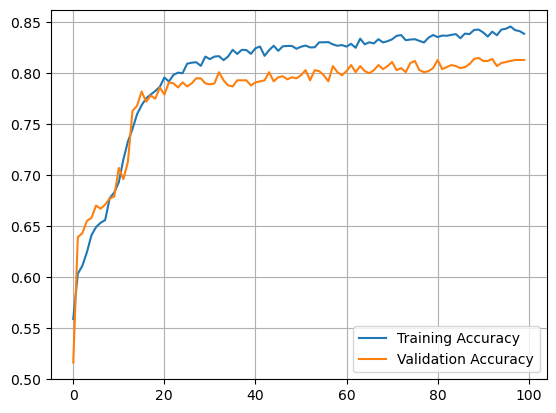

In [138]:
def plot_history_accuracy(history):
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.legend()
    plt.grid()
    plt.show()

plot_history_accuracy(history=history)

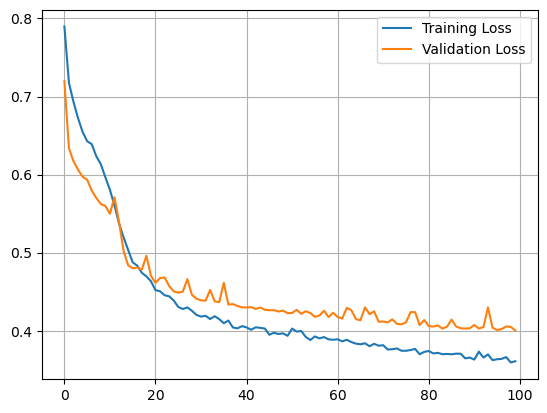

In [139]:
def plot_history_loss(history):
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.legend()
    plt.grid()
    plt.show()

plot_history_loss(history=history)

In [140]:
X_test_num = X_test.iloc[:, :126]  # Chọn 126 cột đầu tiên
X_test_text = X_test.iloc[:, -1]   # Chọn cột cuối cùng

# X_test_num = np.array(X_test_num, dtype=np.float32)
X_test_num = X_test_num.to_numpy(dtype=np.float32)
X_test_num_np = X_test_num.reshape(-1, 126, 1).astype(np.float32)

In [141]:
# Định nghĩa độ dài cố định cho X_train_text và X_val_text
max_len = max_length

# Chuyển đổi tất cả thành danh sách cùng kích thước
# X_test_text = np.array([seq[:max_len] + [0] * (max_len - len(seq)) if len(seq) < max_len else seq[:max_len] for seq in X_test_text], dtype=np.int32)
X_test_text = test_sequence_array
X_test_seq = X_test_text.reshape(-1, timesteps, 1)

print("X_train_text shape:", X_test_seq.shape)

X_train_text shape: (1000, 50, 1)


In [142]:
y_prob = model.predict([X_test_seq, X_test_num_np], verbose=True)
#predictions = (predict_prob >= 0.5).astype(int)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


In [143]:
predictions = (y_prob.flatten() >= 0.5).astype(int)

In [144]:
y_prob.ravel()

array([0.69731724, 0.07635459, 0.18311407, 0.4232938 , 0.60855997,
       0.02221928, 0.07016374, 0.14285807, 0.23203398, 0.9953571 ,
       0.03253423, 0.94606435, 0.19119856, 0.46369627, 0.0536113 ,
       0.23628686, 0.9981983 , 0.08615457, 0.2027612 , 0.9842239 ,
       0.17275502, 0.9940174 , 0.90917003, 0.04318742, 0.99287957,
       0.94919425, 0.8955453 , 0.38059002, 0.12355742, 0.09600388,
       0.9490818 , 0.8624792 , 0.1261243 , 0.48481882, 0.947459  ,
       0.9999753 , 0.33018273, 0.38382664, 0.016159  , 0.9324431 ,
       0.9991254 , 0.15128337, 0.87258124, 0.07437488, 0.8290707 ,
       0.99781054, 0.9862231 , 0.64766634, 0.9815756 , 0.13015412,
       0.143001  , 0.07569352, 0.99467725, 0.10768506, 0.9779574 ,
       0.93123657, 0.691275  , 0.3619108 , 0.4519427 , 0.66767627,
       0.99887913, 0.97112083, 0.1631178 , 0.11563955, 0.14798391,
       0.26355037, 0.01605432, 0.19075523, 0.80901265, 0.14249651,
       0.99726194, 0.89349437, 0.07599773, 0.17494816, 0.99830

In [145]:
y_test.shape, predictions.shape

((1000,), (1000,))

In [146]:
#Y_test.tolist()
y_test = y_test.tolist()

In [147]:
from sklearn.metrics import classification_report
import pandas as pd

# Lấy report dạng dict
report_dict = classification_report(
    y_test,
    predictions,
    target_names=['nAMP (Class 0)', 'AMP (Class 1)'],
    output_dict=True
)
# Chuyển thành DataFrame
df_report = pd.DataFrame(report_dict).transpose()

# Lưu ra CSV
df_report.to_csv("AMPDiscover_classification.csv", index=True)

print("Đã lưu AMPDiscover_classification.csv")

Đã lưu AMPDiscover_classification.csv


In [148]:
print(classification_report(y_test, predictions, target_names=['nAMP (Class 0)', 'AMP (Class 1)']))

                precision    recall  f1-score   support

nAMP (Class 0)       0.87      0.85      0.86       500
 AMP (Class 1)       0.86      0.88      0.87       500

      accuracy                           0.86      1000
     macro avg       0.87      0.86      0.86      1000
  weighted avg       0.87      0.86      0.86      1000



In [149]:
from sklearn.metrics import accuracy_score, roc_auc_score

y_test = np.array(y_test).astype(int).flatten()
y_pred_prob = y_prob.astype(float).flatten()
y_pred_label = (y_pred_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_pred_prob)
acc = accuracy_score(y_test, y_pred_label)

print(f"\n Accuracy:  {acc:.4f}")
print(f" AUC Score: {auc:.4f}")


 Accuracy:  0.8650
 AUC Score: 0.9202


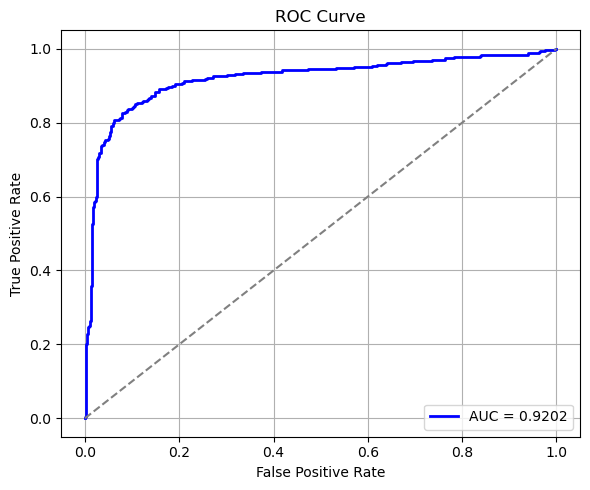

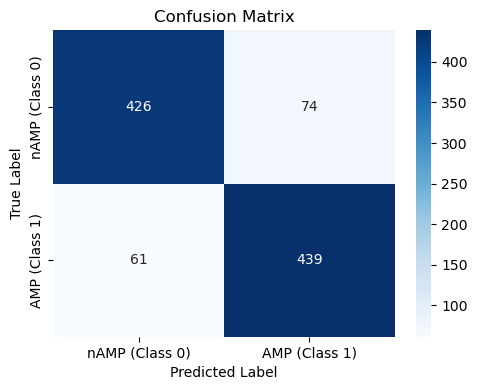


Confusion Matrix Breakdown:
True Positives (TP): 439
False Positives (FP): 74
False Negatives (FN): 61
True Negatives (TN): 426

Precision: 0.8558
Recall:    0.8780
F1-score:  0.8667


In [150]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_score, recall_score, f1_score

# === 1. ROC Curve ===
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# === 2. Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred_label)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["nAMP (Class 0)", "AMP (Class 1)"],
            yticklabels=["nAMP (Class 0)", "AMP (Class 1)"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# === 3. Tính TP, FP, FN, TN ===
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Negatives (TN): {tn}")

# === 4. Precision, Recall, F1-score thủ công ===
precision = precision_score(y_test, y_pred_label)
recall = recall_score(y_test, y_pred_label)
f1 = f1_score(y_test, y_pred_label)

print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")


# EXPLAINABLE AI

In [77]:
model.load_weights('LSTM_GenBank_weights.best.weights.h5')

In [78]:
def compute_saliency_sequence_branch(model, input_seq_tensor, input_num_tensor):
    input_seq_tensor = tf.convert_to_tensor(input_seq_tensor)
    input_seq_tensor = tf.cast(input_seq_tensor, tf.float32)
    input_num_tensor = tf.convert_to_tensor(input_num_tensor)
    input_num_tensor = tf.cast(input_num_tensor, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(input_seq_tensor)

        prediction = model([input_seq_tensor, input_num_tensor], training=False)

    grads = tape.gradient(prediction, input_seq_tensor)

    if grads is None:
        raise ValueError("Gradient could not be computed. Ensure input is used in computation graph.")
    
    saliency = tf.abs(grads).numpy()
    return saliency

In [79]:
# Giả sử bạn muốn giải thích cho sample đầu tiên
x_seq = X_val_seq[1:2]  # (1, 50, 1)
x_num = X_val_num_np[1:2]   # (1, 126, 1)

# Tính saliency
saliency_map = compute_saliency_sequence_branch(model, x_seq, x_num)  # (1, 50, 1)

# Tính độ quan trọng tại từng vị trí (mean theo chiều cuối)
mean_saliency = np.mean(saliency_map[0], axis=-1)  # (50,)

ValueError: Gradient could not be computed. Ensure input is used in computation graph.

In [80]:
# 1. Tạo ánh xạ ngược từ số về ký tự
index_to_char = {v: k.upper() for k, v in tokenizer.word_index.items()}
index_to_char[0] = 'PAD'

# 2. Flatten và chuyển token
token_indices = x_seq[0].flatten().astype(int)
feature_names = [index_to_char.get(idx, '?') for idx in token_indices]

# 3. Lọc bỏ PAD khỏi cả feature_names và mean_saliency
filtered_feature_names = []
filtered_saliency = []

for name, score in zip(feature_names, mean_saliency):
    if name != 'PAD':
        filtered_feature_names.append(name)
        filtered_saliency.append(score)

NameError: name 'mean_saliency' is not defined

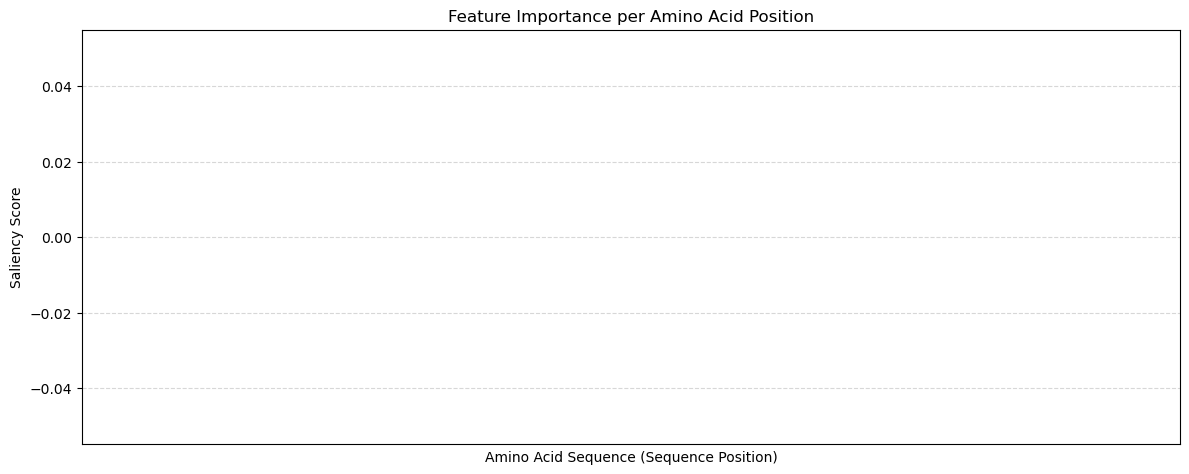

In [81]:
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(filtered_saliency)), filtered_saliency, color='skyblue')
plt.xticks(range(len(filtered_saliency)), filtered_feature_names, rotation=90)
plt.xlabel("Amino Acid Sequence (Sequence Position)")
plt.ylabel("Saliency Score")
plt.title("Feature Importance per Amino Acid Position")
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()

In [82]:
! pip install lime


In [83]:

from lime.lime_text import LimeTextExplainer
from lime.lime_tabular import LimeTabularExplainer

In [84]:
X_test_seq.shape, X_test_num_np.shape

((6000, 50, 1), (6000, 126, 1))

In [85]:
feature_names = np.array([f'c{i}' for i in range(50)] + [f'x{i}' for i in range(126)])
feature_names

array(['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9', 'c10',
       'c11', 'c12', 'c13', 'c14', 'c15', 'c16', 'c17', 'c18', 'c19',
       'c20', 'c21', 'c22', 'c23', 'c24', 'c25', 'c26', 'c27', 'c28',
       'c29', 'c30', 'c31', 'c32', 'c33', 'c34', 'c35', 'c36', 'c37',
       'c38', 'c39', 'c40', 'c41', 'c42', 'c43', 'c44', 'c45', 'c46',
       'c47', 'c48', 'c49', 'x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6',
       'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16',
       'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25',
       'x26', 'x27', 'x28', 'x29', 'x30', 'x31', 'x32', 'x33', 'x34',
       'x35', 'x36', 'x37', 'x38', 'x39', 'x40', 'x41', 'x42', 'x43',
       'x44', 'x45', 'x46', 'x47', 'x48', 'x49', 'x50', 'x51', 'x52',
       'x53', 'x54', 'x55', 'x56', 'x57', 'x58', 'x59', 'x60', 'x61',
       'x62', 'x63', 'x64', 'x65', 'x66', 'x67', 'x68', 'x69', 'x70',
       'x71', 'x72', 'x73', 'x74', 'x75', 'x76', 'x77', 'x78', 'x79',
       'x80'

In [86]:
feature_names.shape

(176,)

In [87]:
index_to_char
for i in range(126):
    index_to_char[22 + i] = data.columns[2+i]
index_to_char

{1: 'R',
 2: 'A',
 3: 'L',
 4: 'K',
 5: 'V',
 6: 'G',
 7: 'S',
 8: 'T',
 9: 'P',
 10: 'I',
 11: 'Q',
 12: 'N',
 13: 'E',
 14: 'F',
 15: 'D',
 16: 'Y',
 17: 'H',
 18: 'M',
 19: 'W',
 20: 'C',
 21: 'X',
 0: 'PAD',
 22: 'hydrophobicity_polar_first',
 23: 'hydrophobicity_polar_20%',
 24: 'hydrophobicity_polar_40%',
 25: 'hydrophobicity_polar_60%',
 26: 'hydrophobicity_polar_80%',
 27: 'hydrophobicity_polar_100%',
 28: 'hydrophobicity_neutral_first',
 29: 'hydrophobicity_neutral_20%',
 30: 'hydrophobicity_neutral_40%',
 31: 'hydrophobicity_neutral_60%',
 32: 'hydrophobicity_neutral_80%',
 33: 'hydrophobicity_neutral_100%',
 34: 'hydrophobicity_hydrophobic_first',
 35: 'hydrophobicity_hydrophobic_20%',
 36: 'hydrophobicity_hydrophobic_40%',
 37: 'hydrophobicity_hydrophobic_60%',
 38: 'hydrophobicity_hydrophobic_80%',
 39: 'hydrophobicity_hydrophobic_100%',
 40: 'vdw_volume_small_first',
 41: 'vdw_volume_small_20%',
 42: 'vdw_volume_small_40%',
 43: 'vdw_volume_small_60%',
 44: 'vdw_volume_sm

In [88]:
data.columns

Index(['Label', 'Sequence', 'hydrophobicity_polar_first',
       'hydrophobicity_polar_20%', 'hydrophobicity_polar_40%',
       'hydrophobicity_polar_60%', 'hydrophobicity_polar_80%',
       'hydrophobicity_polar_100%', 'hydrophobicity_neutral_first',
       'hydrophobicity_neutral_20%',
       ...
       'solvent_accessibility_intermediate_40%',
       'solvent_accessibility_intermediate_60%',
       'solvent_accessibility_intermediate_80%',
       'solvent_accessibility_intermediate_100%',
       'solvent_accessibility_exposed_first',
       'solvent_accessibility_exposed_20%',
       'solvent_accessibility_exposed_40%',
       'solvent_accessibility_exposed_60%',
       'solvent_accessibility_exposed_80%',
       'solvent_accessibility_exposed_100%'],
      dtype='object', length=128)

In [89]:
X_test_seq.shape, X_test_num_np.shape

((6000, 50, 1), (6000, 126, 1))

In [90]:

X = np.concat([X_test_text, X_test_num], axis=1)
#model.predict([X[:,:50,:], X[:,50:,:]])
X.shape


(6000, 176)

In [91]:
# Đếm số lần xuất hiện của từng amino acid
counts = Counter(X_train[2][:50].astype(int))

# Độ dài chuỗi peptide
length = len(data_amp['Sequence'][2])

# Tính tần suất
freq = {index_to_char[aa]: round(count / length, 3) for aa, count in counts.items() if aa > 0}

# In kết quả
print("Tan suat tung amino acid:")
for aa in sorted(freq):
    print(f"{aa}: {freq[aa]}")

KeyError: 2

In [92]:
plt.figure(figsize=(10, 4))
plt.bar(freq.keys(), freq.values(), color='skyblue')
plt.xlabel("Amino Acid")
plt.ylabel("Tan suat")
plt.title("Tan suat cac amino acid trong chuoi peptide")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


NameError: name 'freq' is not defined

<Figure size 1000x400 with 0 Axes>

In [93]:


# Giả sử bạn đã có:
# model        - Mô hình LSTM đã huấn luyện
# tokenizer    - Đối tượng tokenizer đã fit trên dữ liệu
# max_length   - Độ dài chuỗi đầu vào của mô hình

# CLASS NAMES
class_names = ['nAMP (Class 0)', 'AMP (Class 1)']

# Hàm ánh xạ văn bản → xác suất đầu ra của mô hình
def predict_prob(X):
    X_seq = X[:,:50].astype(int)
    X_num =  X[:,50:]
    
    return model.predict([X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1), X_num.reshape(X_num.shape[0], X_num.shape[1], 1)])


#print(X_train.shape)
X_train = np.concat([X_test_text, X_test_num], axis=1)
#print(X_train.shape)
#print([f'word_{i}' for i in range(X_train.shape[1])])
#predict_prob = model.predict()
# Tạo đối tượng explainer
#explainer = LimeTextExplainer(class_names=class_names)
x_sample = X_train[0]
explainer = LimeTabularExplainer(
    training_data=X_train,  # dữ liệu số (tokenized hoặc numerical)
    #feature_names=[f'word_{i}' for i in range(X_train.shape[1])],
    feature_names=[index_to_char[v] for v in x_sample[:50]] + [data.columns[2 + i] for i in range(126)],
    #feature_names=feature_names,
    class_names=class_names,
    #mode='classification',
    discretize_continuous=True
)

# Chọn 1 văn bản cần giải thích
#sample_text = "The movie was really exciting and well-acted."

# Tạo giải thích với LIME
#X = [X_test_seq, X_test_num_np]

explanation = explainer.explain_instance(
    x_sample,               # văn bản gốc
    predict_prob,              # hàm dự đoán
    num_features=50,           # số từ quan trọng cần giải thích
    top_labels=1               # giải thích nhãn dự đoán hàng đầu
)

# Hiển thị
#explanation.show_in_notebook()


157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step


c:\Users\DELL\anaconda3\envs\machineleaTutoria\Lib\site-packages\lime\lime_tabular.py:372: UserWarning: 
                    Prediction probabilties do not sum to 1, and
                    thus does not constitute a probability space.
                    Check that you classifier outputs probabilities
                    (Not log probabilities, or actual class predictions).
                    
  warnings.warn("""


In [238]:
#help(explainer.explain_instance)


In [319]:
#explanation.show_in_notebook()


In [94]:
[u  for u, v in explanation.as_list(label=0)if 'PAD' not in u]

['M > 11.00',
 'R <= 2.00',
 'L <= 3.00',
 'R <= 3.00',
 'L <= 3.00',
 '3.00 < K <= 6.00',
 '3.00 < G <= 6.00',
 '3.00 < G <= 6.00',
 '3.00 < V <= 6.00',
 '0.10 < hydrophobicity_hydrophobic_first <= 0.20',
 '6.00 < P <= 11.00',
 'charge_negative_first <= 0.00',
 'charge_negative_40% <= 0.00',
 'polarizability_high_40% <= 0.30',
 'secondary_structure_coil_20% > 0.44',
 '0.29 < solvent_accessibility_intermediate_20% <= 0.43',
 '0.10 < vdw_volume_medium_first <= 0.20',
 'charge_negative_100% <= 0.00',
 'hydrophobicity_polar_80% <= 0.80',
 'charge_neutral_first > 0.19',
 'polarity_neutral_80% > 0.90',
 '0.75 < charge_neutral_80% <= 0.83',
 'hydrophobicity_polar_40% <= 0.36',
 '0.30 < polarity_nonpolar_40% <= 0.42',
 'hydrophobicity_polar_60% <= 0.50',
 '0.17 < polarizability_medium_first <= 0.30',
 'hydrophobicity_neutral_first > 0.30',
 'solvent_accessibility_intermediate_60% > 0.80',
 '0.60 < solvent_accessibility_buried_60% <= 0.70',
 '0.19 < polarizability_medium_20% <= 0.27',
 '0.90 <

[('M > 11.00', -0.16675790006825622), ('R <= 2.00', 0.15740936262026833), ('L <= 3.00', 0.14865456349856154), ('R <= 3.00', 0.11329683682671908), ('L <= 3.00', 0.10947249932130904), ('3.00 < K <= 6.00', 0.0774572484232245), ('3.00 < G <= 6.00', 0.07624056801565694), ('3.00 < G <= 6.00', 0.07313719570180328), ('3.00 < V <= 6.00', 0.06433654581450275), ('0.10 < hydrophobicity_hydrophobic_first <= 0.20', 0.03741607712026127), ('6.00 < P <= 11.00', -0.0350845414201794), ('charge_negative_first <= 0.00', 0.033229898837913135), ('charge_negative_40% <= 0.00', 0.03302019500092084), ('polarizability_high_40% <= 0.30', 0.03289902373779478), ('secondary_structure_coil_20% > 0.44', 0.031091629056990578), ('0.29 < solvent_accessibility_intermediate_20% <= 0.43', 0.02826117626959219), ('0.10 < vdw_volume_medium_first <= 0.20', 0.028092466151086966), ('charge_negative_100% <= 0.00', -0.027447407646994663), ('hydrophobicity_polar_80% <= 0.80', 0.02640747969742849), ('charge_neutral_first > 0.19', 0.0

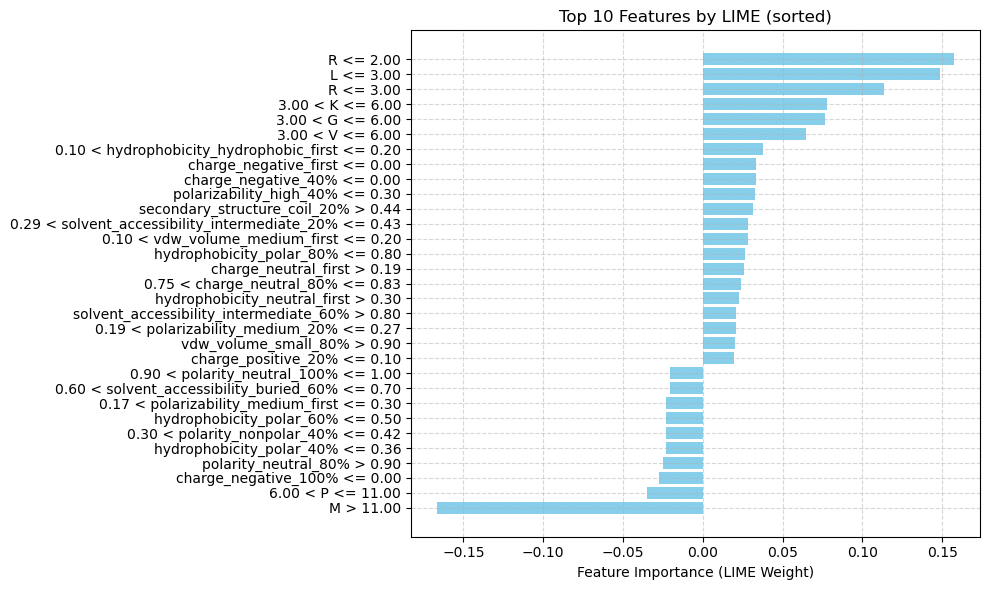

In [95]:
# Lấy 10 feature quan trọng nhất cho class đầu tiên (hoặc top_labels[0])
top_features = [(u, v)  for u, v in explanation.as_list(label=0)if 'PAD' not in u]
print(top_features)

# Sắp xếp giảm dần theo giá trị ảnh hưởng
top_features_sorted = sorted(top_features, key=lambda x: x[1], reverse=True)

# Tách tên và giá trị
feature_names = [f[0] for f in top_features_sorted]
feature_values = [f[1] for f in top_features_sorted]

# Vẽ biểu đồ cột ngang
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_values, color='skyblue')
plt.xlabel("Feature Importance (LIME Weight)")
plt.title("Top 10 Features by LIME (sorted)")
plt.gca().invert_yaxis()  # đảo trục để feature quan trọng nhất ở trên cùng
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [96]:

explanation.available_labels()

[np.int64(0)]